In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential #Builds layer one by one 
from tensorflow.keras.layers import Dense #creates a fully connected layer

In [3]:
#Create a simple feed forward neural network 
model = Sequential() 
model.add(Dense(4, activation="relu", input_shape=(2,))) #input layer with 2 features and hidden layer with 4 neurons
model.add(Dense(3, activation="relu")) #hidden layer with 3 neurons
model.add(Dense(1, activation="sigmoid")) #output layer with 1 neuron for binary classification

e:\git_projects\job-assistant\backend\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(
    optimizer = "adam", #Adam updates the weights based on the error and the learning rate
    loss = "binary_crossentropy", #Binary crossentropy is used for binary classification problems
    metrics = ["accuracy"] #evaulate performance
)

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

['acting' 'amazing' 'boring' 'brad' 'excellent' 'favorite' 'film' 'good'
 'hate' 'in' 'is' 'love' 'movie' 'movies' 'my' 'of' 'one' 'pitt' 'story'
 'terrible' 'this' 'very' 'was']

Numeric representation
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.71422904
  0.52450778 0.         0.         0.         0.         0.
  0.         0.         0.46343118 0.         0.        ]
 [0.         0.56483754 0.         0.         0.         0.
  0.47707078 0.         0.         0.         0.56483754 0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.36649773 0.         0.        ]
 [0.66627085 0.         0.         0.         0.         0.
  0.         0.56274297 0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.48928877 0.        ]
 [0.         0.         0.         0.         0.76396534 0.
  0.         0.

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 9)              │           216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226 (904.00 B)

 Trainable params: 226 (904.00 B)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

Probability: 0.91535854
Positive


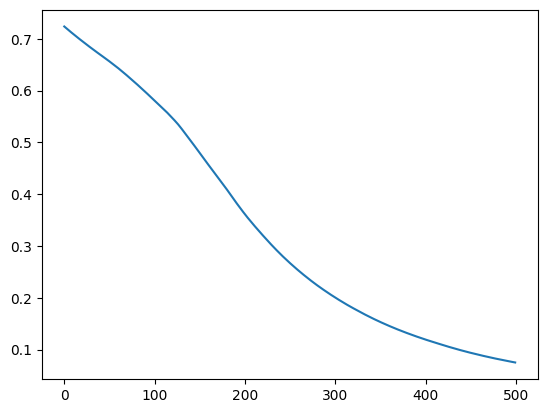

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


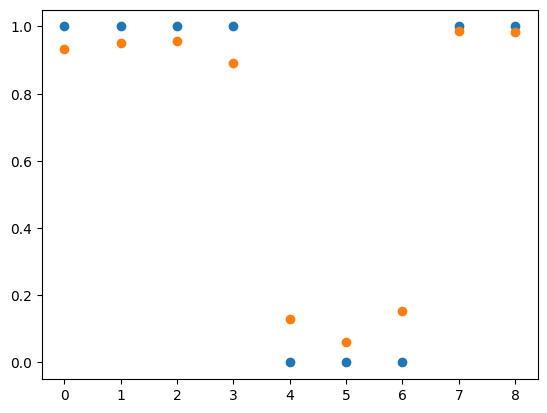

In [8]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np

texts = [
    "I love this movie",
    "This film is amazing",
    "Very good acting",
    "Excellent Story",
    "I hate this movie",
    "Terrible film",
    "Very boring story",
    "Brad Pitt was very good in this movie",
    "One of my Favorite movies"
]

#labels
# 1 = Positive
# 0 = Negative
labels = np.array([1, 1, 1, 1, 0, 0, 0, 1, 1])

#Create a bag of words vectorizer
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(texts).toarray()
#Show all words learned from the dataset
print(vectorizer.get_feature_names_out())

print("\nNumeric representation")
print(X)

#Build a simple feed forward neural network
model = Sequential()
model.add(Dense(9, activation ='relu', input_shape=(X.shape[1],))) #input layer with number of features and hidden layer with 8 neurons
model.add(Dense(1, activation = 'sigmoid')) #output layer with 1 neuron for binary classification
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

model.summary()

#train the model
history = model.fit(
    X, labels, epochs=500, verbose=0
)

new_texts = [
    "Fantastic movies would watch again",
    "Beautiful story and great acting",
    "I do not like this movie",
    "Binged this movie and it was amazing",
    "This movie was terrible and I hated it",
    "Brad Pitt was very bad in this movie",
]

new_vector = vectorizer.transform(new_texts).toarray()

predictions = model.predict(new_vector)

print("\nProbability:", predictions[0][0])

if predictions[0][0] > 0.5:
    print("Positive")
else:
    print("Negative")


import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.show()

predictions = model.predict(X).flatten()

plt.scatter(range(len(labels)),labels)
plt.scatter(range(len(predictions)),predictions)
plt.show()

In [ ]:
#Do the same exercise but with using wordtovec embeddings instead of tfidf vectors

from gensim.models import Word2Vec

texts = [
    "I love this movie",
    "This film is amazing",
    "Very good acting",
    "Excellent Story",
    "I hate this movie",
    "Terrible film",
    "Very boring story",
    "Brad Pitt was very good in this movie",
    "One of my Favorite movies"
]

model = Word2Vec(
    sentences = texts,
    vector_size = 100, #size of the word vectors
    window = 5, #context window size
    min_count = 1, #minimum count of words to consider 
    workers = 4, #number of threads to use
    sg = 1 #use skip-gram model (1) or CBOW model (0
)

